# Bearing Data Exploration
This notebook visualizes the physical characteristics (RMS, Kurtosis, Crest Factor) of a bearing dataset over its full life-cycle. 
This is useful for identifying the start of degradation and determining if the data is suitable for training or evaluation.

In [1]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.auto import tqdm

# Add project root to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../"))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.data import BearingDataset

In [2]:
# --- Data Integrity Check & Auto-Preprocessing ---
raw_root = os.path.abspath(os.path.join(project_root, "data/raw"))
processed_root = os.path.abspath(os.path.join(project_root, "data/processed"))
config_path = os.path.abspath(os.path.join(project_root, "configs/default.yaml"))
pipeline_path = os.path.abspath(os.path.join(project_root, "src/data/pipeline.py"))
venv_python = os.path.abspath(os.path.join(project_root, "venv/bin/python3"))

# Get all bearing IDs from raw data
bearing_ids = sorted([d for d in os.listdir(raw_root) if os.path.isdir(os.path.join(raw_root, d)) and d.startswith('B')])
print(f"Found bearings in raw data: {bearing_ids}")

for b_id in bearing_ids:
    raw_dir = os.path.join(raw_root, b_id)
    processed_dir = os.path.join(processed_root, b_id)
    
    if not os.path.exists(processed_dir):
        print(f"\n>>> Missing processed data for {b_id}. Running pipeline...")
        # Execute pipeline script via shell using project venv
        import subprocess
        cmd = [venv_python, pipeline_path, "--config", config_path, "--raw_dir", raw_dir, "--processed_dir", processed_dir]
        print(f"Executing: {' '.join(cmd)}")
        subprocess.run(cmd, check=True)
    else:
        print(f"Data for {b_id} is already processed.")

print("\nData integrity check complete.")

Found bearings in raw data: ['B01', 'B02', 'B03', 'B04', 'B05']
Data for B01 is already processed.
Data for B02 is already processed.
Data for B03 is already processed.
Data for B04 is already processed.
Data for B05 is already processed.

Data integrity check complete.


In [3]:
# --- Configuration for Exploration Loop ---
LOOKBACK = 4096
HORIZON = 1024
STRIDE = 1024

print(f"Will process bearings: {bearing_ids}")

Will process bearings: ['B01', 'B02', 'B03', 'B04', 'B05']


In [4]:
# --- Feature Extraction Loop for All Bearings ---
all_bearing_features = {}

for b_id in bearing_ids:
    processed_dir = os.path.join(processed_root, b_id)
    print(f"\nProcessing bearing: {b_id} from {processed_dir}")
    
    # Initialize dataset (using 'test' split to get all files without training-specific skipping)
    dataset = BearingDataset(
        data_dir=processed_dir, 
        lookback=LOOKBACK, 
        horizon=HORIZON, 
        stride=STRIDE, 
        split='test', 
        normalize=False, 
        skip_ratio=0.0 # Don't skip anything for exploration
    )

    all_files = dataset.files
    print(f"Total files found: {len(all_files)}")
    
    file_indices = []
    file_rms = []
    file_kurtosis = []
    file_crest_factor = []

    print(f"Extracting features from {b_id}...")
    for i, f_name in enumerate(tqdm(all_files, desc=f"Features {b_id}")):
        f_path = os.path.join(processed_dir, f_name)
        signal = torch.load(f_path, weights_only=True) # (2, N)
        
        # 1. RMS (already cached in dataset)
        rms = dataset.file_rms[f_name]
        
        # 2. Extract window for Kurtosis and Crest Factor (middle window)
        mid = signal.shape[1] // 2
        x = signal[:, mid:mid+LOOKBACK]
        
        # Stats per channel then average
        # Peak-to-RMS ratio = Crest Factor
        peak = torch.max(torch.abs(x), dim=-1)[0]
        rms_win = torch.sqrt(torch.mean(x**2, dim=-1))
        crest = (peak / (rms_win + 1e-8)).mean().item()
        
        # Kurtosis
        mean = x.mean(dim=-1, keepdim=True)
        std = x.std(dim=-1, keepdim=True)
        z = (x - mean) / (std + 1e-8)
        kurt = torch.mean(z**4, dim=-1).mean().item()
        
        file_indices.append(i)
        file_rms.append(rms)
        file_kurtosis.append(kurt)
        file_crest_factor.append(crest)
        
    all_bearing_features[b_id] = {
        'rms': file_rms,
        'kurtosis': file_kurtosis,
        'crest_factor': file_crest_factor,
        'indices': file_indices
    }

print("\nExtraction complete for all bearings.")


Processing bearing: B01 from /mnt/f/APPS_PJ/mamba-forecast-ad/data/processed/B01
Computing per-file RMS for B01...
Total files found: 377
Extracting features from B01...


Features B01:   0%|          | 0/377 [00:00<?, ?it/s]


Processing bearing: B02 from /mnt/f/APPS_PJ/mamba-forecast-ad/data/processed/B02
Total files found: 1116
Extracting features from B02...


Features B02:   0%|          | 0/1116 [00:00<?, ?it/s]


Processing bearing: B03 from /mnt/f/APPS_PJ/mamba-forecast-ad/data/processed/B03
Computing per-file RMS for B03...
Total files found: 614
Extracting features from B03...


...


Processing bearing: B04 from /mnt/f/APPS_PJ/mamba-forecast-ad/data/processed/B04
Total files found: 1114
Extracting features from B04...


Features B04:   0%|          | 0/1114 [00:00<?, ?it/s]


Processing bearing: B05 from /mnt/f/APPS_PJ/mamba-forecast-ad/data/processed/B05
Computing per-file RMS for B05...
Total files found: 572
Extracting features from B05...


Features B05:   0%|          | 0/572 [00:00<?, ?it/s]


Extraction complete for all bearings.


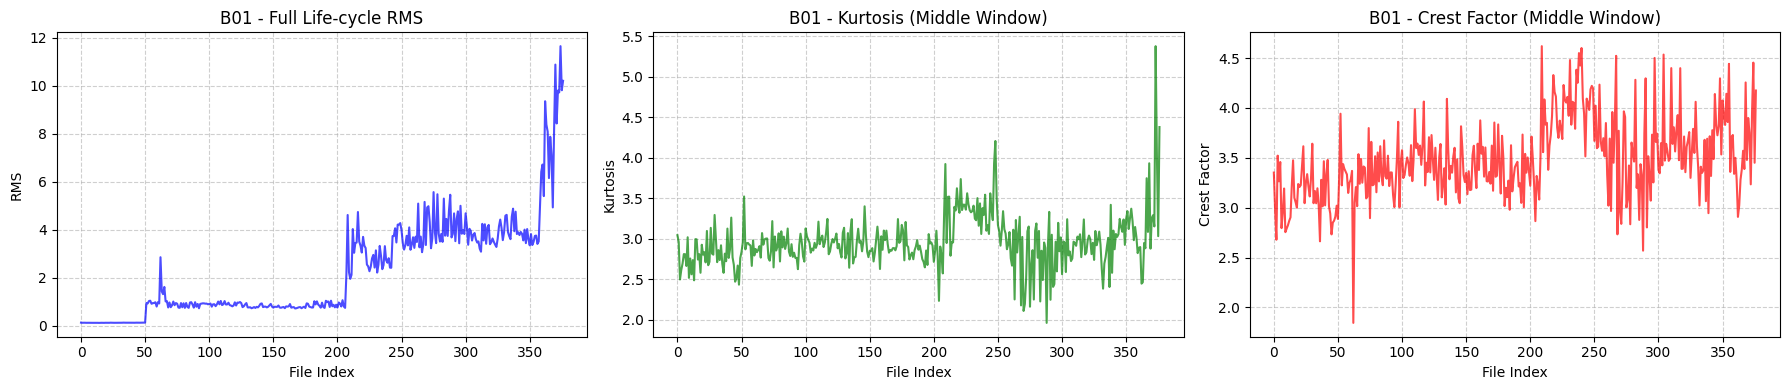

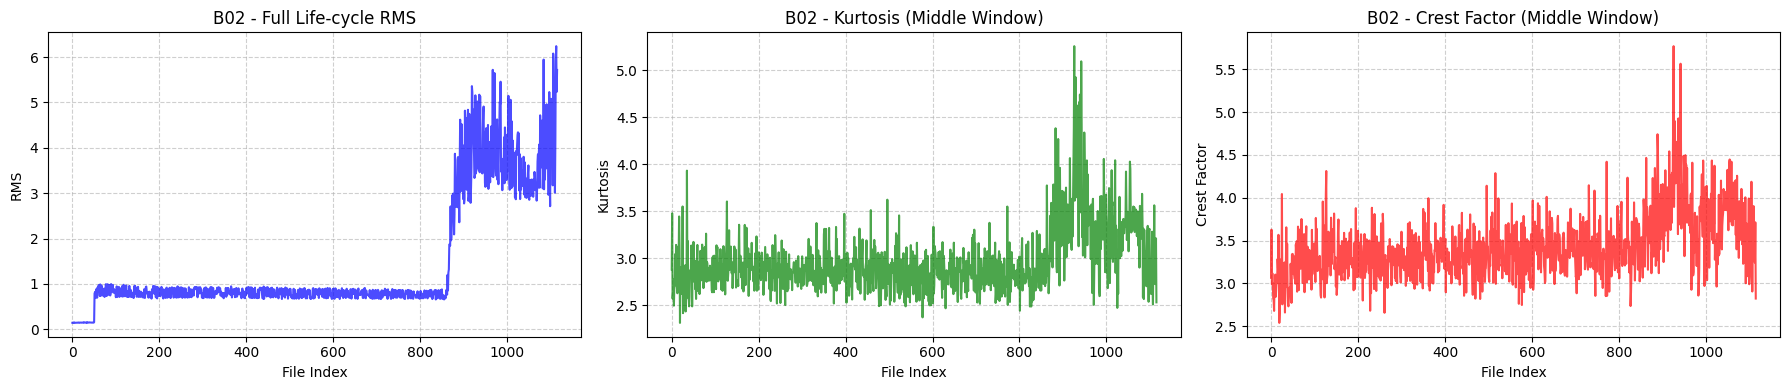

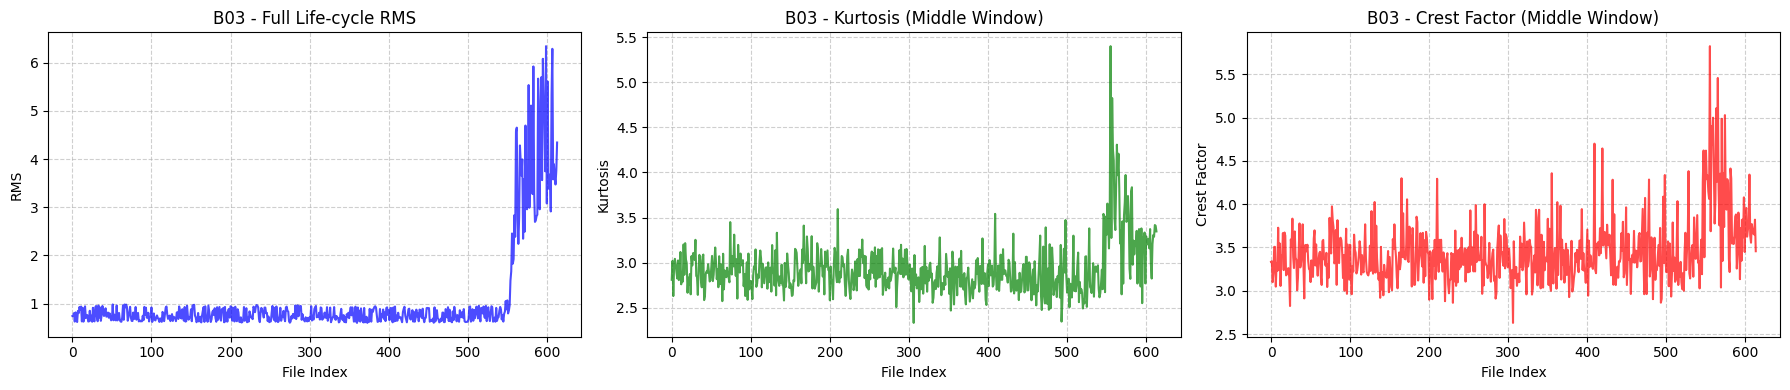

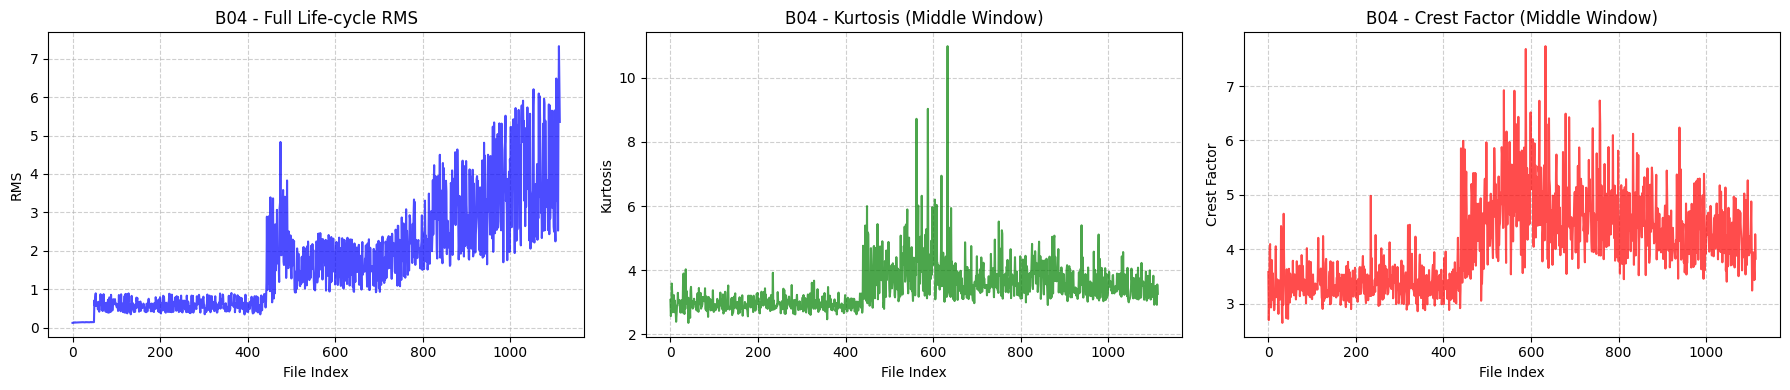

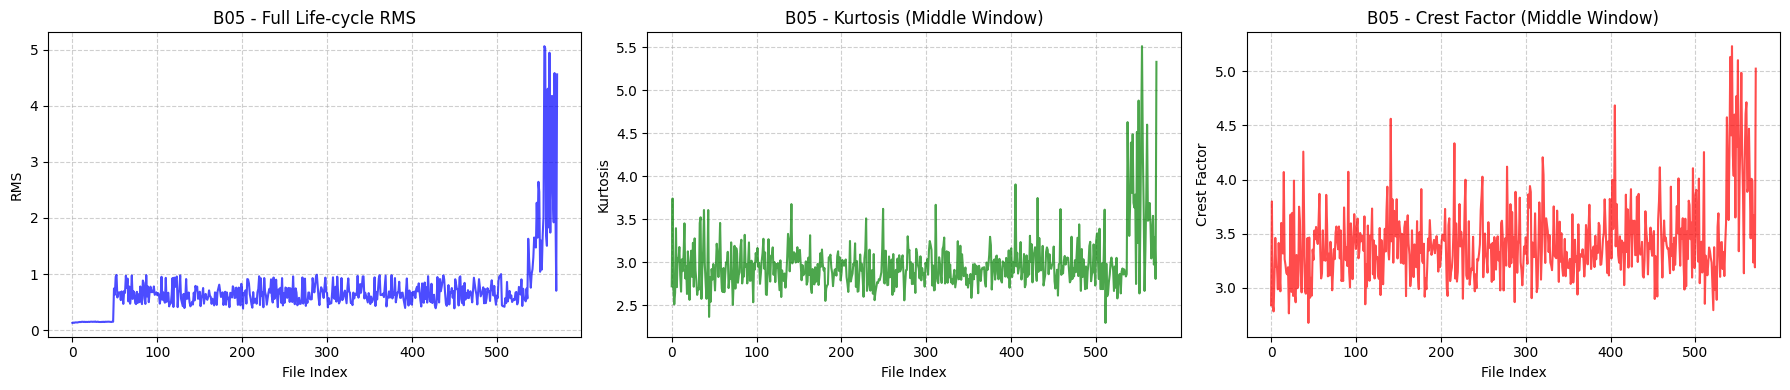

In [5]:
# --- Visualization of All Bearings ---
for b_id, features in all_bearing_features.items():
    plt.figure(figsize=(18, 4))
    
    # 1. RMS
    plt.subplot(1, 3, 1)
    plt.plot(features['indices'], features['rms'], color='blue', alpha=0.7)
    plt.title(f"{b_id} - Full Life-cycle RMS")
    plt.xlabel("File Index")
    plt.ylabel("RMS")
    plt.grid(True, linestyle='--', alpha=0.6)

    # 2. Kurtosis
    plt.subplot(1, 3, 2)
    plt.plot(features['indices'], features['kurtosis'], color='green', alpha=0.7)
    plt.title(f"{b_id} - Kurtosis (Middle Window)")
    plt.xlabel("File Index")
    plt.ylabel("Kurtosis")
    plt.grid(True, linestyle='--', alpha=0.6)

    # 3. Crest Factor
    plt.subplot(1, 3, 3)
    plt.plot(features['indices'], features['crest_factor'], color='red', alpha=0.7)
    plt.title(f"{b_id} - Crest Factor (Middle Window)")
    plt.xlabel("File Index")
    plt.ylabel("Crest Factor")
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()